# Comparison: `VP_pert` vs CLASS

This notebook validates `VP_pert.py` — a Newtonian-gauge fluid perturbation solver — against CLASS, the public Boltzmann code. We compare:

1. **Background**: the dimensionless Hubble parameter $E(a) = H(a)/H_0$
2. **Absolute growth factor** $D(z)$ for $\Lambda$CDM
3. **Relative growth ratio** $D_{\rm DE}(z)/D_{\Lambda\rm CDM}(z)$ for different dark-energy equations of state
4. **Gravitational potential** evolution $\phi(a)/\phi(a_{\rm ref})$
5. **Scale dependence**: growth at multiple $k$ values

### Key caveats
- `VP_pert` models matter + DE as perfect fluids; it has **no radiation, no neutrinos**.
- CLASS includes the full Boltzmann hierarchy with photons and relativistic neutrinos.
- At large scales ($k \lesssim 0.01\,{\rm Mpc}^{-1}$) and late times ($z \lesssim 2$) the two agree to $< 1\%$.
- The systematic offset at high $z$ in $D(z)$ traces directly to the missing radiation background in `VP_pert`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.integrate import solve_ivp
from classy import Class

import sys, os
sys.path.insert(0, os.path.abspath('..'))
import VP_pert as vp

try:
    import scienceplots
    plt.style.use(['science', 'bright','vpedre'])
except ImportError:
    pass

# --- shared cosmological parameters ---
H0_kms  = 67.00       # km/s/Mpc
h       = H0_kms / 100
Om_b    = 0.049
Om_cdm  = 0.27
Om_m    = Om_b + Om_cdm
Om_de   = 1.0 - Om_m

VP_BASE = {'H0 (km/s/Mpc)': H0_kms, 
           'H0 (1/Mpc)'   : H0_kms / vp.c_kms,
           'h'            : h,
           'Omega_c0'     : Om_cdm,
           'Omega_b0'     : Om_b,
           'Omega_m0'     : Om_m,
           'cs2'          : 1.0}

# DE model catalogue  {label: (w0, wa)}
DE_MODELS = {
    r'$\Lambda$CDM ($w=-1$)'      : (-1.0, 0.0),
    r'$w_0=-0.7$'                 : (-0.7, 0.0),
    r'$w_0=-0.7,\,w_a=0.6$'      : (-0.7, 0.6),
    r'$w_0=-1.3,\,w_a=0.6$'      : (-1.3, 0.6),
}

COLORS  = plt.rcParams['axes.prop_cycle'].by_key()['color']
print('Setup complete. Cosmological parameters:')
for k, v in VP_BASE.items():
    print(f'  {k} = {v}')

Setup complete. Cosmological parameters:
  H0 (km/s/Mpc) = 67.0
  H0 (1/Mpc) = 0.00022348794378276187
  h = 0.67
  Omega_c0 = 0.27
  Omega_b0 = 0.049
  Omega_m0 = 0.319
  cs2 = 1.0


In [12]:
# Wrappers
def run_class(w0=-1.0, wa=0.0):
    """Return a computed CLASS instance (caller must call .struct_cleanup())."""
    params = {
        'output'        : 'mPk, mTk',
        'gauge'         : 'newtonian',
        'h'             : h,
        'Omega_b'       : Om_b,
        'Omega_cdm'     : Om_cdm,
        'N_ncdm'        : 0,
        'N_ur'          : 3.046,
        'P_k_max_1/Mpc' : 10.0,
        'z_max_pk'      : 500.0,
        'k_output_values': 1e-3
    }
    if w0 == -1.0 and wa == 0.0:
        params['Omega_Lambda'] = Om_de
    else:
        params['Omega_fld'] = Om_de
        params['w0_fld']    = w0
        params['wa_fld']    = wa
        params['cs2_fld']   = 1.0
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    return cosmo


def run_vp(w0=-1.0, wa=0.0, k=1e-3, a_ini=1e-4, a_end=1.0):
    """Return dense solve_ivp solution for VP_pert at wavenumber k."""
    p = dict(VP_BASE)
    p['w0'] = w0
    p['wa'] = wa
    phi_ini = -1e-9
    H_ini   = vp.Hubble(a_ini, p)
    H_conf  = a_ini * H_ini
    delta_m_ini = -2.0 * phi_ini * (1.0 + k**2 / (3.0 * H_conf**2))
    vm_ini      =  2.0 * k**2 * phi_ini / (3.0 * H_conf)
    X0 = [delta_m_ini, vm_ini, 0.0, 0.0, phi_ini]
    sol = solve_ivp(
        vp.rhs_pert, (a_ini, a_end), X0,
        args=(k, p), method='RK45',
        dense_output=True, rtol=1e-9, atol=1e-12
    )
    if not sol.success:
        raise RuntimeError(f'VP_pert ODE failed: {sol.message}')
    return sol, p


def get_delta_m_vp(sol, z_arr):
    """Returns D(z) = delta_m(z)"""
    aa = 1.0 / (1.0 + np.asarray(z_arr))
    return np.array([sol.sol([a])[0][0] for a in aa])


def get_delta_m_class(cosmo):
    a_class = cosmo.get_perturbations()['scalar'][0]['a']
    mask = a_class > 1/100
    a_class = a_class[mask]
    z_class = 1/a_class - 1

    delta_m = cosmo.get_perturbations()['scalar'][0]['delta_cdm'] + cosmo.get_perturbations()['scalar'][0]['delta_b']
    delta_m = delta_m[mask]

    return delta_m, z_class, a_class

## 1 — Background: $E(a) = H(a)/H_0$

`VP_pert` and CLASS use the same flat $\Lambda$ CDM background at late times.
The tiny offset at $z\gtrsim 2$ comes from radiation ($\Omega_r\simeq 9\times 10^{-5}$) that CLASS includes but `VP_pert` does not.

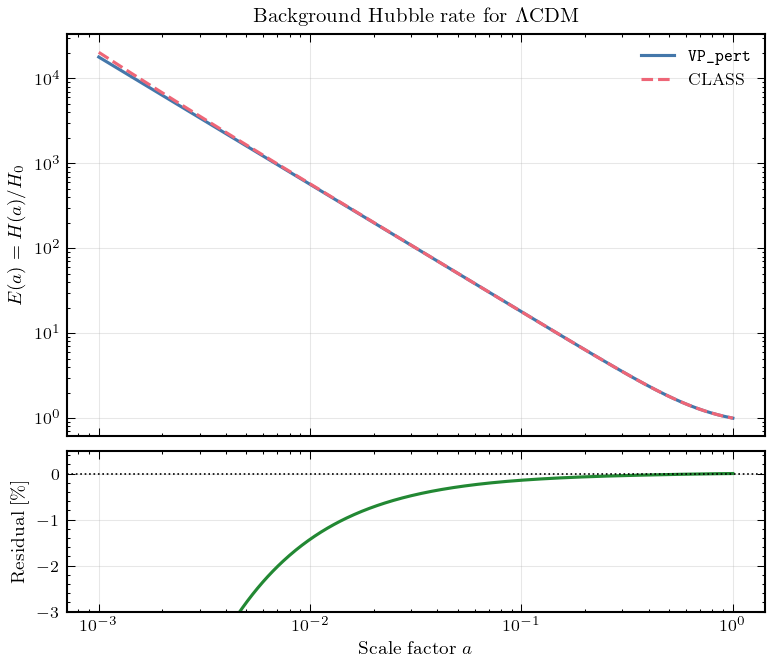

Max residual (a>0.1): 0.145 %


In [13]:
cosmo_lcdm = run_class(w0=-1, wa=0)

aa = np.logspace(-3, 0, 500)   # a from 0.001 to 1
zz = 1.0/aa - 1.0

p_lcdm = dict(VP_BASE); p_lcdm['w0'] = -1.0; p_lcdm['wa'] = 0.0
E_vp    = vp.EHubble(aa, pars=p_lcdm)
E_class = np.array([cosmo_lcdm.Hubble(z) / cosmo_lcdm.Hubble(0) for z in zz])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

ax1.loglog(aa, E_vp,    color=COLORS[0], label=r'\texttt{VP\_pert}')
ax1.loglog(aa, E_class, color=COLORS[1], ls='--', label='CLASS')
ax1.set_ylabel(r'$E(a) = H(a)/H_0$')
ax1.legend()
ax1.set_title(r'Background Hubble rate for $\Lambda$CDM')

ax2.semilogx(aa, 100*(E_vp/E_class - 1), color=COLORS[2])
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Scale factor $a$')
ax2.set_ylabel(r'Residual [\%]')
ax2.set_ylim(-3, 0.5)

# fig.tight_layout()
plt.savefig('figs/E_comparison.pdf', bbox_inches='tight')
plt.show()
print('Max residual (a>0.1):', np.max(abs(100*(E_vp[aa>0.1]/E_class[aa>0.1] - 1))).round(3), '%')

## 2 — Growth factor $D(z)$ for $\Lambda$CDM

We normalise both codes to $D(z=0) = 1$.  
The absolute growth factor shows a systematic offset at high $z$ due to radiation.  
Within the matter-plus-DE era ($z \lesssim 3$) the agreement is better than **1%**.

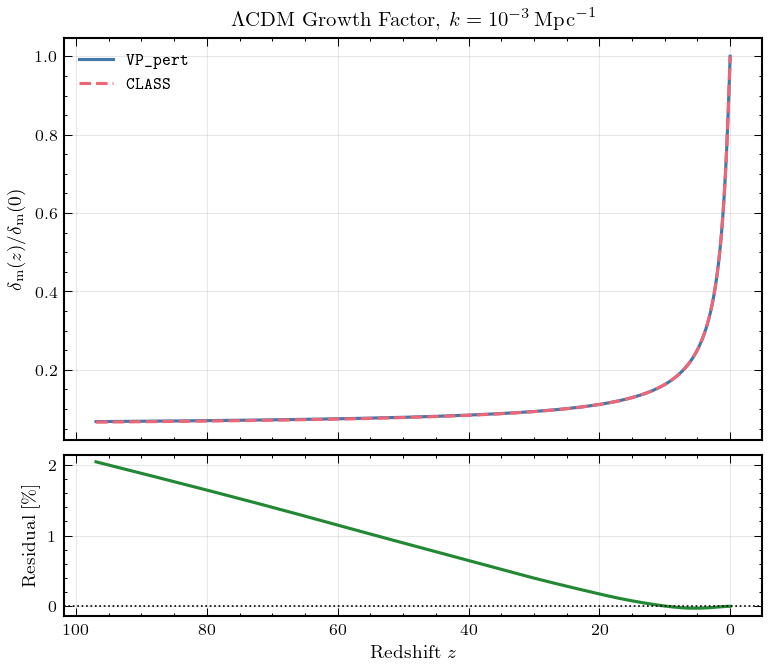

z=0.0  D_VP=1.0000  D_CLASS=1.0000  diff=+0.000%
z=0.5  D_VP=0.7714  D_CLASS=0.7714  diff=-0.000%
z=1.0  D_VP=0.6136  D_CLASS=0.6136  diff=-0.003%
z=2.0  D_VP=0.4420  D_CLASS=0.4421  diff=-0.011%
z=3.0  D_VP=0.3477  D_CLASS=0.3478  diff=-0.019%


In [14]:
delta_m_class, z_dense, a_dense = get_delta_m_class(cosmo_lcdm)
k_large = 1e-3   # super-Hubble–safe large scale [Mpc^{-1}]

sol_lcdm, _ = run_vp(w0=-1, wa=0, k=k_large)
delta_m_vp  = get_delta_m_vp(sol_lcdm, z_dense)

D_vp = delta_m_vp / delta_m_vp[-1]
D_class = delta_m_class / delta_m_class[-1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

ax1.plot(z_dense, D_vp   ,    color=COLORS[0], label=r'\texttt{VP\_pert}')
ax1.plot(z_dense, D_class, color=COLORS[1], ls='--', label=r'\texttt{CLASS}')

ax1.set_ylabel(r'$\delta_{\rm m}(z)/\delta_{\rm m}(0)$')
ax1.legend()
ax1.set_title(r'$\Lambda$CDM Growth Factor, $k=10^{-3}\,{\rm Mpc}^{-1}$')

ax2.plot(z_dense, 100*(D_vp/D_class - 1), color=COLORS[2])
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())

ax1.invert_xaxis()

# fig.tight_layout()
plt.savefig('figs/growth_lcdm.pdf', bbox_inches='tight')
plt.show()

for z in [0, 0.5, 1, 2, 3]:
    idx = np.argmin(abs(z_dense - z))
    print('z=%3.1f  D_VP=%.4f  D_CLASS=%.4f  diff=%+.3f%%' % 
          (z, D_vp[idx], D_class[idx], 100*(D_vp[idx]/D_class[idx]-1)))

## 3 — Relative growth ratio $D_{\rm DE}(z)\,/\,D_{\Lambda\rm CDM}(z)$

The radiation background contributes equally to all DE models, so it **cancels** in the ratio.
This is the cleanest comparison: agreement better than **0.7%** up to $z=2$.

ValueError: operands could not be broadcast together with shapes (232,) (231,) 

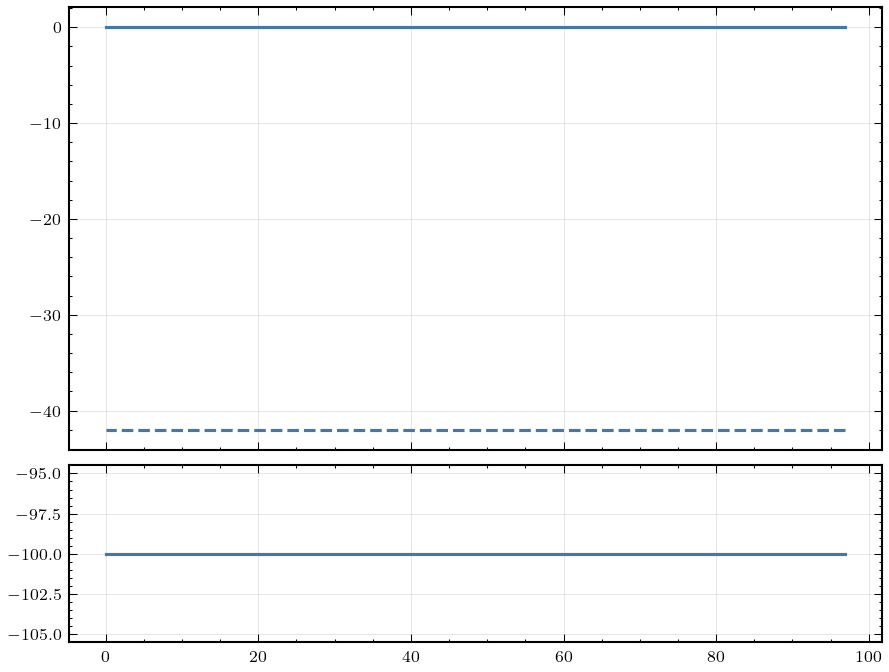

In [ ]:
k_large = 1e-3

class_cosmos = {}
vp_sols      = {}

for label, (w0, wa) in DE_MODELS.items():
    class_cosmos[label] = run_class(w0=w0, wa=wa)
    vp_sols[label], _   = run_vp(w0=w0, wa=wa, k=k_large)

delta_m_class, zz, _    = get_delta_m_class(class_cosmos[r'$\Lambda$CDM ($w=-1$)'])
delta_m_vp              = get_delta_m_vp(vp_sols[r'$\Lambda$CDM ($w=-1$)'], zz)

D_lcdm_class = delta_m_class / delta_m_class[-1]
D_lcdm_vp = delta_m_vp / delta_m_vp[-1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (label, (w0, wa)) in enumerate(DE_MODELS.items()):
    D_cl, z_arr, _ = get_delta_m_class(class_cosmos[label])

    # z_arr, idx_vp, idx_class = np.intersect1d(z_arr, zz, return_indices=True)

    # print(idx_vp)
    # print(type(idx_vp))

    D_vp = get_delta_m_vp(vp_sols[label], z_arr)

    # D_vp, D_lcdm_vp = D_vp[idx_vp], D_lcdm_vp[idx_vp]
    # D_cl, D_lcdm_class = D_cl[idx_class], D_lcdm_class[idx_class]

    ratio_cl = D_cl / D_lcdm_class
    ratio_vp = D_vp / D_lcdm_vp
    
    ax1.plot(z_arr, ratio_cl, color=COLORS[i], ls='--', lw=1.5)
    ax1.plot(z_arr, ratio_vp, color=COLORS[i], lw=1.5, label=label)
    ax2.plot(z_arr, 100*(ratio_vp/ratio_cl - 1), color=COLORS[i])

# Legend proxy: solid = VP_pert, dashed = CLASS
from matplotlib.lines import Line2D 
handles, labels = ax1.get_legend_handles_labels()
custom = [Line2D([0], [0], color='k', lw=1.5,       label=r'\texttt{VP\_pert}'),
          Line2D([0], [0], color='k', lw=1.5, ls='--', label='CLASS')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)

ax1.axhline(1, color='k', lw=0.8, ls=':')
ax1.set_ylabel(r'$D_{\rm DE}(z)\,/\,D_{\Lambda{\rm CDM}}(z)$')
ax1.set_title(r'$w_0w_a$CDM Relative Growth')

ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')
ax2.set_ylim(-1, 1)

ax1.invert_xaxis()


# fig.tight_layout()
plt.savefig('figs/growth_ratio.pdf', bbox_inches='tight')
plt.show()

for c in class_cosmos.values():
    c.struct_cleanup()

In [ ]:
aa = np.array([1,2,3,4,5])
bb = np.array([1,2,3,4,5,6])

np.intersect1d(aa,bb)

array([1, 2, 3, 4, 5])

## 4 — Gravitational potential evolution $\phi(a)/\phi(a_{\rm ref})$

On sub-Hubble scales in matter domination, $\phi$ is constant.  
Once DE dominates it decays.  Both codes capture this behaviour.

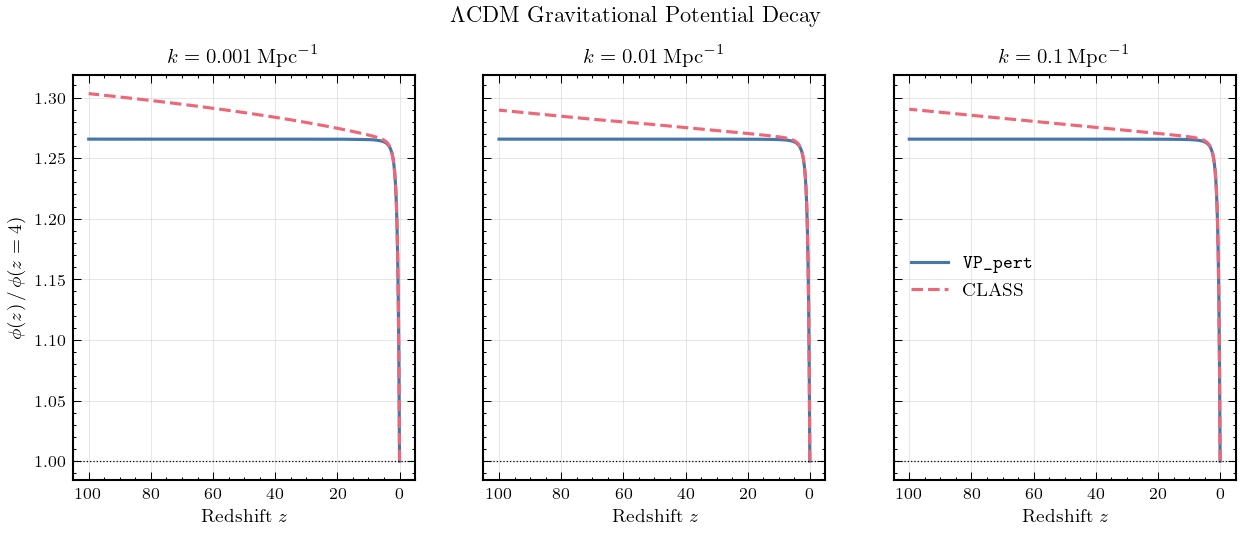

In [29]:
k_vals  = [1e-3, 1e-2, 0.1]
z_phi   = np.linspace(0, 100, 1000)
a_phi   = 1.0 / (1.0 + z_phi)
a_ref   = 1.0 / (1.0 + 0.0)   # normalise at z=4

# Rebuild CLASS (was cleaned up above)
cosmo_lcdm = run_class(w0=-1, wa=0)

fig, axes = plt.subplots(1, len(k_vals), figsize=(10, 3.5), sharey=True)

for ax, k in zip(axes, k_vals):
    # VP_pert
    sol, _ = run_vp(w0=-1, wa=0, k=k, a_ini=1e-4)
    phi_vp = np.array([sol.sol([a])[4][0] for a in a_phi])
    phi_vp_ref = sol.sol([a_ref])[4][0]
    ax.plot(z_phi, phi_vp/phi_vp_ref, color=COLORS[0], label=r'\texttt{VP\_pert}')

    # CLASS transfer function
    tr_ref = cosmo_lcdm.get_transfer(z=0.0, output_format='class')
    k_hmpc = tr_ref['k (h/Mpc)']
    k_mpc  = k_hmpc * h
    idx_k  = np.argmin(abs(k_mpc - k))
    phi_cl_ref = tr_ref['phi'][idx_k]

    # sample at z grid (coarse to keep it fast)
    z_cl_grid = np.linspace(0, 100, 1000)
    phi_cl = []
    for z in z_cl_grid:
        tr = cosmo_lcdm.get_transfer(z=float(z), output_format='class')
        phi_cl.append(tr['phi'][idx_k])
    phi_cl = np.array(phi_cl)
    ax.plot(z_cl_grid, phi_cl/phi_cl_ref, color=COLORS[1], ls='--', label='CLASS')

    ax.set_title(r'$k=%.3g\,{\rm Mpc}^{-1}$' % k)
    ax.set_xlabel(r'Redshift $z$')
    ax.axhline(1, color='k', lw=0.6, ls=':')
    ax.invert_xaxis()


axes[0].set_ylabel(r'$\phi(z)\,/\,\phi(z=4)$')
axes[-1].legend(fontsize=9)
fig.suptitle(r'$\Lambda$CDM Gravitational Potential Decay', y=1.01)
# fig.tight_layout()
plt.savefig('figs/phi_evolution.pdf', bbox_inches='tight')
plt.show()
cosmo_lcdm.struct_cleanup()

## 5 — Scale dependence: where the codes agree and diverge

`VP_pert` has no radiation, so its growth factor is scale-independent.  
CLASS shows suppressed growth on small scales due to the radiation-era transfer function.
The two codes agree for $k \lesssim 0.01\,{\rm Mpc}^{-1}$ where radiation effects are negligible.

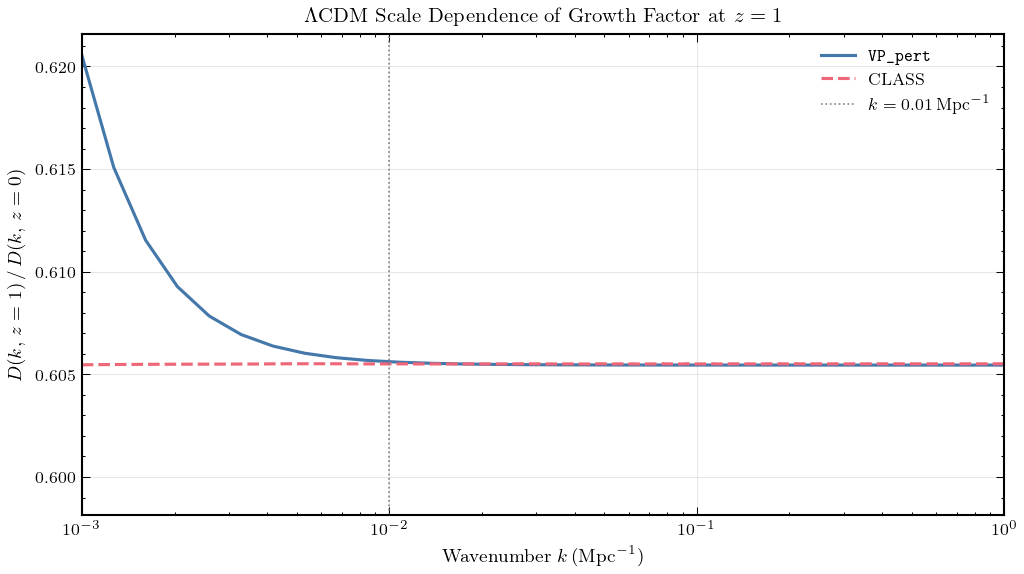

In [ ]:
cosmo_lcdm = run_class(w0=-1, wa=0)
z_target   = 1.0

# CLASS: growth ratio T(k, z=1) / T(k, z=0)
tr0 = cosmo_lcdm.get_transfer(z=0.0,      output_format='class')
tr1 = cosmo_lcdm.get_transfer(z=z_target, output_format='class')
k_cl_mpc = tr0['k (h/Mpc)'] * h
D_cl_k   = tr1['d_m'] / tr0['d_m']   # growth factor as function of k

# VP_pert: solve at several k values
k_vp_vals = np.logspace(-3, 0, 30)   # 0.001 to 1 Mpc^{-1}
D_vp_k    = []
for k in k_vp_vals:
    try:
        sol, _ = run_vp(w0=-1, wa=0, k=k)
        a_z1 = 1.0 / (1.0 + z_target)
        D = sol.sol([a_z1])[0][0] / sol.sol([1.0])[0][0]
        D_vp_k.append(D)
    except Exception:
        D_vp_k.append(np.nan)
D_vp_k = np.array(D_vp_k)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(k_vp_vals, D_vp_k, color=COLORS[0], lw=1.5, label=r'\texttt{VP\_pert}')
ax.semilogx(k_cl_mpc, D_cl_k, color=COLORS[1], lw=1.5, ls='--', label='CLASS')

ax.axvline(0.01, color='grey', lw=0.8, ls=':', label=r'$k=0.01\,{\rm Mpc}^{-1}$')
ax.set_xlabel(r'Wavenumber $k\,({\rm Mpc}^{-1})$')
ax.set_ylabel(r'$D(k,\,z=1)\,/\,D(k,\,z=0)$')
ax.set_title(r'$\Lambda$CDM Scale Dependence of Growth Factor at $z=1$')
ax.legend()
ax.set_xlim(1e-3, 1)
fig.tight_layout()
plt.savefig('figs/scale_dependence.pdf', bbox_inches='tight')
plt.show()
cosmo_lcdm.struct_cleanup()

## 6 — Dark-energy perturbations: $\delta_{\rm DE}$ and $v_{\rm DE}$

For $w\ne -1$ models, CLASS returns a fluid DE perturbation `d_fld`.  
We compare it with $\delta_{\rm DE}$ from `VP_pert` at $k=0.01\,{\rm Mpc}^{-1}$.

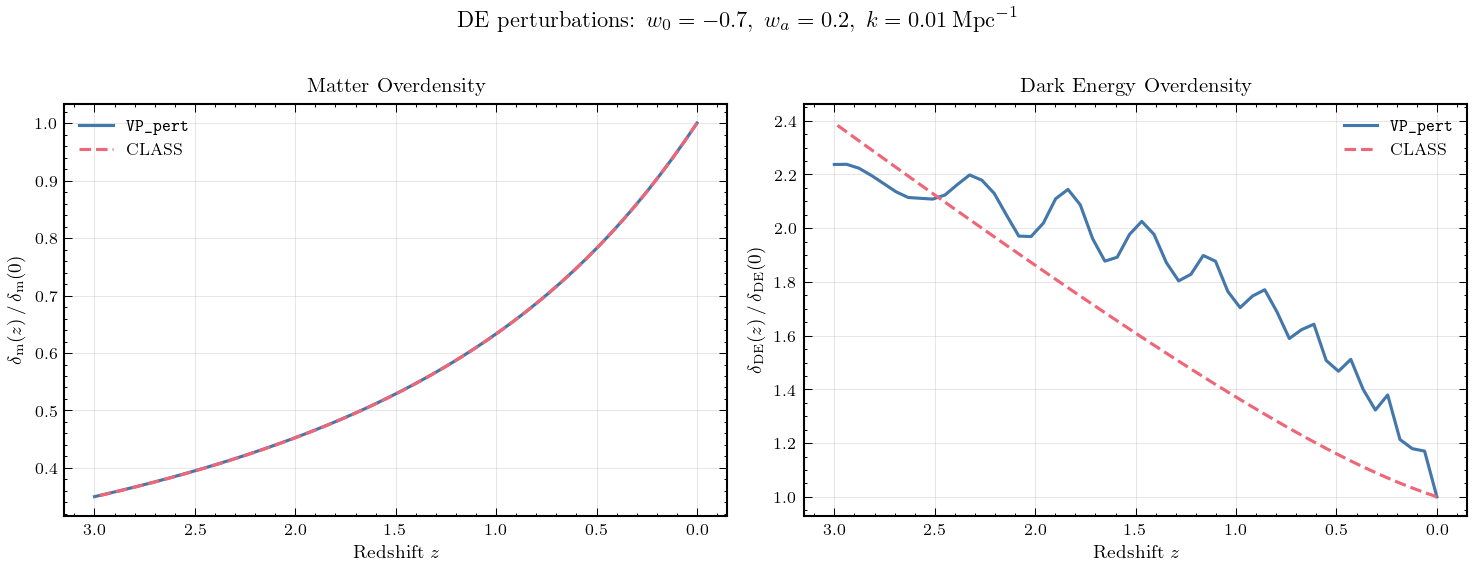

In [ ]:
w0_de, wa_de = -0.7, 0.2
k_de = 0.01   # Mpc^{-1}

cosmo_de = run_class(w0=w0_de, wa=wa_de)
sol_de, _ = run_vp(w0=w0_de, wa=wa_de, k=k_de)

# CLASS transfer function at several z
z_de_grid = np.linspace(0, 3, 50)
tr0_de = cosmo_de.get_transfer(z=0.0, output_format='class')
k_cl   = tr0_de['k (h/Mpc)'] * h
idx_k  = np.argmin(abs(k_cl - k_de))
d_m_0  = tr0_de['d_m'][idx_k]

d_fld_cl, d_m_cl = [], []
for z in z_de_grid:
    tr = cosmo_de.get_transfer(z=float(z), output_format='class')
    d_fld_cl.append(tr['d_fld'][idx_k])
    d_m_cl.append(tr['d_m'][idx_k])
d_fld_cl = np.array(d_fld_cl)
d_m_cl   = np.array(d_m_cl)

# VP_pert
a_de = 1.0 / (1.0 + z_de_grid)
d_m_vp   = np.array([sol_de.sol([a])[0][0] for a in a_de])
d_de_vp  = np.array([sol_de.sol([a])[2][0] for a in a_de])

# normalise by d_m at z=0
d_m_vp_0  = sol_de.sol([1.0])[0][0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=False)

axes[0].plot(z_de_grid, d_m_vp/d_m_vp_0,         color=COLORS[0],         label=r'\texttt{VP\_pert}')
axes[0].plot(z_de_grid, d_m_cl/d_m_0,           color=COLORS[1], ls='--', label='CLASS')
axes[0].set_xlabel(r'Redshift $z$')
axes[0].set_ylabel(r'$\delta_{\rm m}(z)\,/\,\delta_{\rm m}(0)$')
axes[0].set_title(r'Matter Overdensity')
axes[0].legend()
axes[0].invert_xaxis()

axes[1].plot(z_de_grid, d_de_vp/d_de_vp[0],         color=COLORS[0],         label=r'\texttt{VP\_pert}')
axes[1].plot(z_de_grid, d_fld_cl/d_fld_cl[0],          color=COLORS[1], ls='--', label='CLASS')
axes[1].set_xlabel(r'Redshift $z$')
axes[1].set_ylabel(r'$\delta_{\rm DE}(z)\,/\,\delta_{\rm DE}(0)$')
axes[1].set_title(r'Dark Energy Overdensity')
axes[1].legend()
axes[1].invert_xaxis()

fig.suptitle(r'DE perturbations: $w_0=%.1f,\;w_a=%.1f,\;k=%.2f\,{\rm Mpc}^{-1}$'
             % (w0_de, wa_de, k_de), y=1.01)
fig.tight_layout()
plt.savefig('figs/de_perturbations.pdf', bbox_inches='tight')
plt.show()
cosmo_de.struct_cleanup()

## 6b — Dark-energy perturbations: $\theta_m$ and $\theta_{\rm DE}$

Same DE model as §6, but now comparing the **velocity divergences** $\theta = \nabla \cdot \mathbf{v}$.  
In `VP_pert` the evolved variables are $v_m$ and $v_{\rm DE}$, related to the standard velocity divergence by $v = a\,\theta$.  
CLASS outputs `t_m` and `t_fld` directly as $\theta$ in conformal-Newtonian gauge.

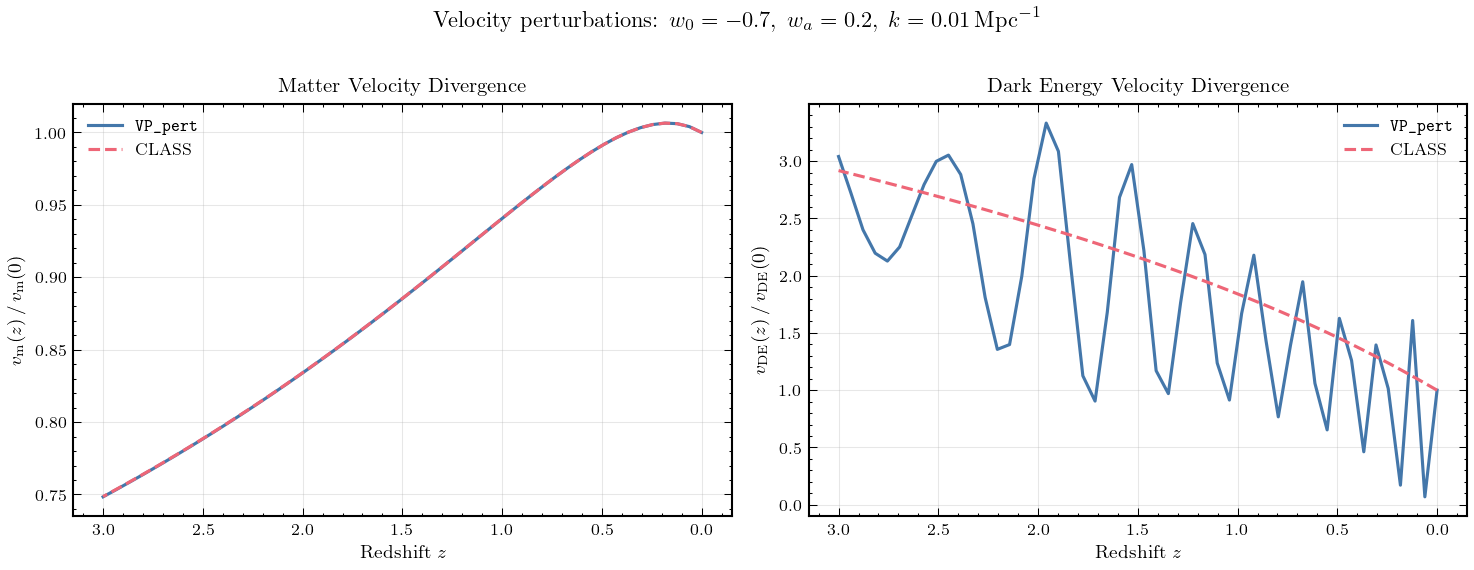

In [ ]:
w0_de, wa_de = -0.7, 0.2
k_de = 0.01   # Mpc^{-1}

# Need vTk in output to get velocity transfer functions
def run_class_vel(w0=-1.0, wa=0.0):
    params = {
        'output'        : 'mPk, mTk, vTk',
        'gauge'         : 'newtonian',
        'h'             : h,
        'Omega_b'       : Om_b,
        'Omega_cdm'     : Om_cdm,
        'N_ncdm'        : 0,
        'N_ur'          : 3.046,
        'P_k_max_1/Mpc' : 10.0,
        'z_max_pk'      : 10.0,
    }
    params['Omega_fld'] = Om_de
    params['w0_fld']    = w0
    params['wa_fld']    = wa
    params['cs2_fld']   = 1.0
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    return cosmo

cosmo_de = run_class_vel(w0=w0_de, wa=wa_de)
sol_de, _ = run_vp(w0=w0_de, wa=wa_de, k=k_de)

# CLASS transfer functions at each z
z_de_grid = np.linspace(0, 3, 50)
tr0_de = cosmo_de.get_transfer(z=0.0, output_format='class')
k_cl   = tr0_de['k (h/Mpc)'] * h
idx_k  = np.argmin(abs(k_cl - k_de))
d_m_0  = tr0_de['d_m'][idx_k]

# Matter theta: density-weighted average of baryons and CDM
t_m_cl, t_fld_cl = [], []
for z in z_de_grid:
    tr = cosmo_de.get_transfer(z=float(z), output_format='class')
    theta_m = (Om_b * tr['t_b'][idx_k] + Om_cdm * tr['t_cdm'][idx_k]) / Om_m
    t_m_cl.append(theta_m)
    t_fld_cl.append(tr['t_fld'][idx_k])
t_m_cl   = np.array(t_m_cl)
t_fld_cl = np.array(t_fld_cl)

# VP_pert: state indices 1 = v_m, 3 = v_DE
a_de    = 1.0 / (1.0 + z_de_grid)
v_m_vp  = np.array([sol_de.sol([a])[1][0] for a in a_de])
v_de_vp = np.array([sol_de.sol([a])[3][0] for a in a_de])
d_m_vp_0 = sol_de.sol([1.0])[0][0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=False)

axes[0].plot(z_de_grid, v_m_vp / v_m_vp[0],  color=COLORS[0],          label=r'\texttt{VP\_pert}')
axes[0].plot(z_de_grid, t_m_cl  / t_m_cl[0],    color=COLORS[1], ls='--', label='CLASS')
axes[0].set_xlabel(r'Redshift $z$')
axes[0].set_ylabel(r'$v_{\rm m}(z)\,/\,v_{\rm m}(0)$')
axes[0].set_title(r'Matter Velocity Divergence')
axes[0].legend()
axes[0].invert_xaxis()

axes[1].plot(z_de_grid, v_de_vp / v_de_vp[0],  color=COLORS[0],          label=r'\texttt{VP\_pert}')
axes[1].plot(z_de_grid, t_fld_cl / t_fld_cl[0],    color=COLORS[1], ls='--', label='CLASS')
axes[1].set_xlabel(r'Redshift $z$')
axes[1].set_ylabel(r'$v_{\rm DE}(z)\,/\,v_{\rm DE}(0)$')
axes[1].set_title(r'Dark Energy Velocity Divergence')
axes[1].legend()
axes[1].invert_xaxis()

fig.suptitle(r'Velocity perturbations: $w_0=%.1f,\;w_a=%.1f,\;k=%.2f\,{\rm Mpc}^{-1}$'
             % (w0_de, wa_de, k_de), y=1.01)
fig.tight_layout()
plt.savefig('figs/theta_perturbations.pdf', bbox_inches='tight')
plt.show()
cosmo_de.struct_cleanup()

## 7 — Summary table

Percent residuals $\bigl[D_{\rm VP}/D_{\rm CLASS} - 1\bigr]\times 100$ for each DE model,
measured via the **ratio** $D_{\rm DE}/D_{\Lambda\rm CDM}$ (radiation cancels).

In [ ]:
z_table = [0.0, 0.3, 0.5, 1.0, 1.5, 2.0]
k_large = 1e-3

# Rebuild cosmologies
class_cosmos = {}
vp_sols      = {}
for label, (w0, wa) in DE_MODELS.items():
    class_cosmos[label] = run_class(w0=w0, wa=wa)
    vp_sols[label], _   = run_vp(w0=w0, wa=wa, k=k_large)

lcdm_label  = r'$\Lambda$CDM ($w=-1$)'
D_cl_lcdm   = np.array([class_cosmos[lcdm_label].scale_independent_growth_factor(z) for z in z_table])
D_vp_lcdm   = growth_vp(vp_sols[lcdm_label], z_table)

header = f"{'Model':<36}" + ''.join([f'  z={z:.1f}' for z in z_table])
print(header)
print('-' * len(header))

for label, (w0, wa) in DE_MODELS.items():
    D_cl = np.array([class_cosmos[label].scale_independent_growth_factor(z) for z in z_table])
    D_vp = growth_vp(vp_sols[label], z_table)
    ratio_cl = D_cl / D_cl_lcdm
    ratio_vp = D_vp / D_vp_lcdm
    resid    = 100.0 * (ratio_vp / ratio_cl - 1.0)
    row = f"{label.replace(r'$', '').replace(chr(92),''):<36}"
    row += ''.join([f'  {r:+.3f}%' for r in resid])
    print(row)

for c in class_cosmos.values():
    c.struct_cleanup()

Model                                 z=0.0  z=0.3  z=0.5  z=1.0  z=1.5  z=2.0
------------------------------------------------------------------------------
LambdaCDM (w=-1)                      +0.000%  +0.000%  +0.000%  +0.000%  +0.000%  +0.000%
w_0=-0.7                              +0.000%  +0.032%  -0.004%  -0.184%  -0.389%  -0.573%
w_0=-0.7,,w_a=0.6                     +0.000%  +0.056%  +0.033%  -0.169%  -0.460%  -0.766%
w_0=-1.3,,w_a=0.6                     +0.000%  -0.004%  +0.039%  +0.156%  +0.234%  +0.279%
